In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from pathlib import Path
from jax import pmap
from flax.jax_utils import replicate
from flax.training.common_utils import shard
from PIL import Image
from huggingface_hub import notebook_login
import diffusers
from src.pipeline_flax_stable_diffusion import FlaxStableDiffusionPipeline, FlaxUnconditionalStableDiffusionPipeline


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

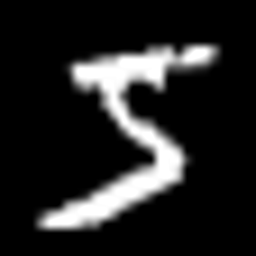

KeyError: 'text'

In [1]:
# dataset visualization
import torchvision
from datasets import load_dataset
ds = load_dataset("mnist", split="train")
for i in range(1):
    sample = ds[i]
    image = sample["image"].resize((256, 256))
    display(image)
    print(sample["text"])
    # image.save('out.png')

In [ ]:
sample.keys()

In [2]:
num_devices = jax.device_count()
device_type = jax.devices()[0].device_kind
print(f"Found {num_devices} JAX devices of type {device_type}.")
assert "TPU" in device_type, "Available device is not a TPU, please select TPU from Edit > Notebook settings > Hardware accelerator"
dtype = jnp.float32
pipeline, params = FlaxUnconditionalStableDiffusionPipeline.from_pretrained(
    # "../diffusers-modulation/sd-pokemon-finetune",
    "sd-cats-unconditional-1000",
    tokenizer=None,
    text_encoder=None,
    safety_checker=None,
    # revision="bf16",
    dtype=dtype,
)
num_inference_steps = 50
num_samples = jax.device_count()
num_samples = 1
# params = replicate(params)


Found 8 JAX devices of type TPU v3.


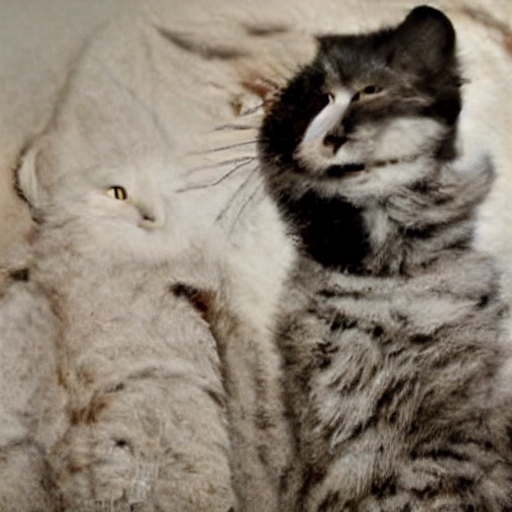

In [3]:
prng_seed = jax.random.PRNGKey(23)
num_samples = 1
# prng_seed = jax.random.split(prng_seed, num_samples)
# prompt = ""
# prompt = num_samples * [prompt]
# prompt_ids = pipeline.prepare_inputs(prompt)
# prompt_ids = shard(prompt_ids)
# prompt_ids.shape
prompt_ids = jnp.zeros((num_samples,1))
images = pipeline(prompt_ids, params, prng_seed, num_inference_steps).images
images = pipeline.numpy_to_pil(np.asarray(images.reshape((num_samples,) + images.shape[-3:])))
images[0]


In [ ]:
for image in images:
    display(image.resize((256,256)))

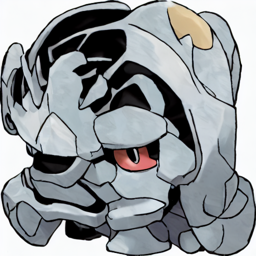

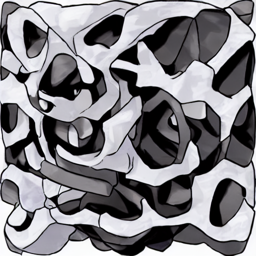

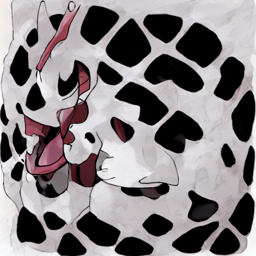

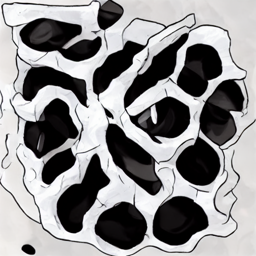

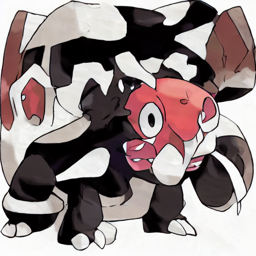

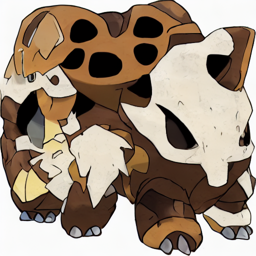

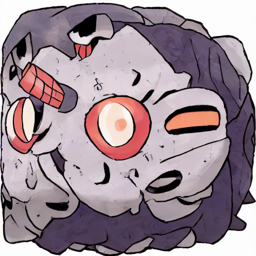

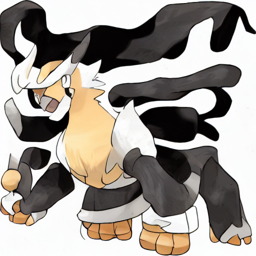

In [15]:
for image in images:
    display(image.resize((256,256)))

In [4]:
# from src.models.unet_2d_condition_flax import FlaxUNet2DConditionModel
# # unet = FlaxUNet2DUnconditionModel()
# import jax

# config = FlaxUNet2DConditionModel.load_config('unet-config-unconditional.json')
# unet = FlaxUNet2DConditionModel.from_config(config)
# unet.config
# rng = jax.random.PRNGKey(23)
# unet.init_weights(rng)
type(pipeline)

src.pipeline_flax_stable_diffusion.FlaxUnconditionalStableDiffusionPipeline

In [5]:
# unet.config

In [6]:
# num_devices = jax.device_count()
# device_type = jax.devices()[0].device_kind
# print(f"Found {num_devices} JAX devices of type {device_type}.")
# assert "TPU" in device_type, "Available device is not a TPU, please select TPU from Edit > Notebook settings > Hardware accelerator"
# dtype = jnp.bfloat16
# pipeline, params = FlaxStableDiffusionPipeline.from_pretrained(
#     # "duongna/stable-diffusion-v1-4-flax",
#     "./sd-pokemon-unconditional",
#     # "./sd-pokemon-retry/",
#     # tokenizer=None,
#     # text_encoder=None,
#     # revision="bf16",
#     dtype=dtype,
# )
# num_inference_steps = 50
# num_samples = jax.device_count()
# params = replicate(params)
# pipeline.safety_checker=None


In [7]:
def printTree(tree, d = 0):
    if (tree == None or len(tree) == 0):
        print("\t" * d, "-")
    else:
        for key, val in tree.items():
            if (isinstance(val, dict)):
                print("\t" * d, key)
                printTree(val, d+1)
            else:
                print("\t" * d,key, val.shape)

printTree(params['unet'])

 conv_in
	 bias (320,)
	 kernel (3, 3, 4, 320)
 conv_norm_out
	 bias (320,)
	 scale (320,)
 conv_out
	 bias (4,)
	 kernel (3, 3, 320, 4)
 down_blocks_0
	 attentions_0
		 norm
			 bias (320,)
			 scale (320,)
		 proj_in
			 bias (320,)
			 kernel (1, 1, 320, 320)
		 proj_out
			 bias (320,)
			 kernel (1, 1, 320, 320)
		 transformer_blocks_0
			 attn1
				 to_k
					 kernel (320, 320)
				 to_out_0
					 bias (320,)
					 kernel (320, 320)
				 to_q
					 kernel (320, 320)
				 to_v
					 kernel (320, 320)
			 attn2
				 to_k
					 kernel (320, 320)
				 to_out_0
					 bias (320,)
					 kernel (320, 320)
				 to_q
					 kernel (320, 320)
				 to_v
					 kernel (320, 320)
			 ff
				 net_0
					 proj
						 bias (2560,)
						 kernel (320, 2560)
				 net_2
					 bias (320,)
					 kernel (1280, 320)
			 norm1
				 bias (320,)
				 scale (320,)
			 norm2
				 bias (320,)
				 scale (320,)
			 norm3
				 bias (320,)
				 scale (320,)
	 attentions_1
		 norm
			 bias (320,)
			 scale (320,)
	

In [8]:
# XLA is slow on TPU
# from diffusers import DiffusionPipeline
# import torch
# import torch_xla.core.xla_model as xm

# model_id = "stabilityai/stable-diffusion-xl-base-1.0"
# pipe = DiffusionPipeline.from_pretrained(model_id)

# device = xm.xla_device()
# pipe.to(device)

# prompt = "A pokemon with green eyes and red legs."
# start = time()
# image = pipe(prompt, num_inference_steps=inference_steps).images[0]
# print(f'Compilation time is {time()-start} sec')
# image.save("pokemon.png")

# start = time()
# image = pipe(prompt, num_inference_steps=inference_steps).images[0]
# print(f'Inference time is {time()-start} sec after compilation')

In [9]:
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")

prompt = "A cinematic shot of a baby racoon wearing an intricate italian priest robe."
image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx